In [10]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

In [11]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [12]:
cars_data = pd.read_csv('/content/drive/MyDrive/ML/Final Project/Cardetails.csv') # Dataset link
cars_data.head()

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,torque,seats
0,Maruti Swift Dzire VDI,2014,450000,145500,Diesel,Individual,Manual,First Owner,23.4 kmpl,1248 CC,74 bhp,190Nm@ 2000rpm,5.0
1,Skoda Rapid 1.5 TDI Ambition,2014,370000,120000,Diesel,Individual,Manual,Second Owner,21.14 kmpl,1498 CC,103.52 bhp,250Nm@ 1500-2500rpm,5.0
2,Honda City 2017-2020 EXi,2006,158000,140000,Petrol,Individual,Manual,Third Owner,17.7 kmpl,1497 CC,78 bhp,"12.7@ 2,700(kgm@ rpm)",5.0
3,Hyundai i20 Sportz Diesel,2010,225000,127000,Diesel,Individual,Manual,First Owner,23.0 kmpl,1396 CC,90 bhp,22.4 kgm at 1750-2750rpm,5.0
4,Maruti Swift VXI BSIII,2007,130000,120000,Petrol,Individual,Manual,First Owner,16.1 kmpl,1298 CC,88.2 bhp,"11.5@ 4,500(kgm@ rpm)",5.0


In [13]:
# Droping unnesesary column
cars_data.drop(columns=['torque'], inplace=True)

In [14]:
cars_data.head()

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,seats
0,Maruti Swift Dzire VDI,2014,450000,145500,Diesel,Individual,Manual,First Owner,23.4 kmpl,1248 CC,74 bhp,5.0
1,Skoda Rapid 1.5 TDI Ambition,2014,370000,120000,Diesel,Individual,Manual,Second Owner,21.14 kmpl,1498 CC,103.52 bhp,5.0
2,Honda City 2017-2020 EXi,2006,158000,140000,Petrol,Individual,Manual,Third Owner,17.7 kmpl,1497 CC,78 bhp,5.0
3,Hyundai i20 Sportz Diesel,2010,225000,127000,Diesel,Individual,Manual,First Owner,23.0 kmpl,1396 CC,90 bhp,5.0
4,Maruti Swift VXI BSIII,2007,130000,120000,Petrol,Individual,Manual,First Owner,16.1 kmpl,1298 CC,88.2 bhp,5.0


In [15]:
cars_data.shape

(8128, 12)

In [16]:
# Preprocessing
# null check
cars_data.isnull().sum()

,0
name,0
year,0
selling_price,0
km_driven,0
fuel,0
seller_type,0
transmission,0
owner,0
mileage,221
engine,221


In [17]:
# Drop all the nulll value
cars_data.dropna(inplace=True)

In [18]:
cars_data.shape

(7907, 12)

In [19]:
# Dublicate chack
cars_data.duplicated().sum()

np.int64(1189)

In [20]:
# Drop all the Dublicate value
cars_data.drop_duplicates(inplace=True)

In [21]:
cars_data.shape

(6718, 12)

In [22]:
cars_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6718 entries, 0 to 8125
Data columns (total 12 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   name           6718 non-null   object 
 1   year           6718 non-null   int64  
 2   selling_price  6718 non-null   int64  
 3   km_driven      6718 non-null   int64  
 4   fuel           6718 non-null   object 
 5   seller_type    6718 non-null   object 
 6   transmission   6718 non-null   object 
 7   owner          6718 non-null   object 
 8   mileage        6718 non-null   object 
 9   engine         6718 non-null   object 
 10  max_power      6718 non-null   object 
 11  seats          6718 non-null   float64
dtypes: float64(1), int64(3), object(8)
memory usage: 682.3+ KB


In [23]:
# Data analysis
for col in cars_data.columns:
  print('Unique value of' + col)
  print(cars_data[col].unique)
  print("======================\n")

Unique value ofname
<bound method Series.unique of 0                  Maruti Swift Dzire VDI
1            Skoda Rapid 1.5 TDI Ambition
2                Honda City 2017-2020 EXi
3               Hyundai i20 Sportz Diesel
4                  Maruti Swift VXI BSIII
                      ...                
8121    Maruti Wagon R VXI BS IV with ABS
8122           Hyundai i20 Magna 1.4 CRDi
8123                    Hyundai i20 Magna
8124                Hyundai Verna CRDi SX
8125               Maruti Swift Dzire ZDi
Name: name, Length: 6718, dtype: object>

Unique value ofyear
<bound method Series.unique of 0       2014
1       2014
2       2006
3       2010
4       2007
        ... 
8121    2013
8122    2014
8123    2013
8124    2007
8125    2009
Name: year, Length: 6718, dtype: int64>

Unique value ofselling_price
<bound method Series.unique of 0       450000
1       370000
2       158000
3       225000
4       130000
         ...  
8121    260000
8122    475000
8123    320000
8124    135000


In [24]:
# Convert from Brand model name to Brand name
def get_brand_name (car_name):
  car_name = car_name.split(' ') [0]
  return car_name.strip()

In [25]:
# Convert from Brand model name to Brand name
def clean_data(value):
  value = value.split(' ') [0]
  value = value.strip()
  if value == '':
     value = 0
  return float(value)

In [26]:
get_brand_name('Maruti Swift Dzire zDi')

'Maruti'

In [27]:
# Apply Brand model name to Brand name
cars_data['name'] = cars_data['name'].apply(get_brand_name)

In [28]:
cars_data['name'].unique()

array(['Maruti', 'Skoda', 'Honda', 'Hyundai', 'Toyota', 'Ford', 'Renault',
       'Mahindra', 'Tata', 'Chevrolet', 'Datsun', 'Jeep', 'Mercedes-Benz',
       'Mitsubishi', 'Audi', 'Volkswagen', 'BMW', 'Nissan', 'Lexus',
       'Jaguar', 'Land', 'MG', 'Volvo', 'Daewoo', 'Kia', 'Fiat', 'Force',
       'Ambassador', 'Ashok', 'Isuzu', 'Opel'], dtype=object)

In [29]:
# For mileage
cars_data['mileage'] = cars_data['mileage'].apply(clean_data)

In [30]:
# For max_power
cars_data['max_power'] = cars_data['max_power'].apply(clean_data)

In [31]:
# For engine
cars_data['engine'] = cars_data['engine'].apply(clean_data)

In [32]:
for col in cars_data.columns:
  print('Unique value of' + col)
  print(cars_data[col].unique)
  print("======================\n")

Unique value ofname
<bound method Series.unique of 0        Maruti
1         Skoda
2         Honda
3       Hyundai
4        Maruti
         ...   
8121     Maruti
8122    Hyundai
8123    Hyundai
8124    Hyundai
8125     Maruti
Name: name, Length: 6718, dtype: object>

Unique value ofyear
<bound method Series.unique of 0       2014
1       2014
2       2006
3       2010
4       2007
        ... 
8121    2013
8122    2014
8123    2013
8124    2007
8125    2009
Name: year, Length: 6718, dtype: int64>

Unique value ofselling_price
<bound method Series.unique of 0       450000
1       370000
2       158000
3       225000
4       130000
         ...  
8121    260000
8122    475000
8123    320000
8124    135000
8125    382000
Name: selling_price, Length: 6718, dtype: int64>

Unique value ofkm_driven
<bound method Series.unique of 0       145500
1       120000
2       140000
3       127000
4       120000
         ...  
8121     50000
8122     80000
8123    110000
8124    119000
8125    120000


In [33]:
# Convert from Categorical to numerical data
cars_data['name'].replace(['Maruti', 'Skoda', 'Honda', 'Hyundai', 'Toyota', 'Ford', 'Renault',
       'Mahindra', 'Tata', 'Chevrolet', 'Datsun', 'Jeep', 'Mercedes-Benz',
       'Mitsubishi', 'Audi', 'Volkswagen', 'BMW', 'Nissan', 'Lexus',
       'Jaguar', 'Land', 'MG', 'Volvo', 'Daewoo', 'Kia', 'Fiat', 'Force',
       'Ambassador', 'Ashok', 'Isuzu', 'Opel'],
        [1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31],
                          inplace=True)

/tmp/ipython-input-1330924603.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  cars_data['name'].replace(['Maruti', 'Skoda', 'Honda', 'Hyundai', 'Toyota', 'Ford', 'Renault',
/tmp/ipython-input-1330924603.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  cars_data['name'].replace(['Maruti', 'Sko

In [34]:
# Convert Transmission
cars_data['transmission'].unique()

array(['Manual', 'Automatic'], dtype=object)

In [35]:
cars_data['transmission'].replace(['Manual', 'Automatic'], [1,2], inplace=True)

/tmp/ipython-input-3759958917.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  cars_data['transmission'].replace(['Manual', 'Automatic'], [1,2], inplace=True)
/tmp/ipython-input-3759958917.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  cars_data['transmission'].replace(['Manual', 'Automatic'

In [36]:
# Convert Seller_type
cars_data['seller_type'].unique()

array(['Individual', 'Dealer', 'Trustmark Dealer'], dtype=object)

In [37]:
cars_data['seller_type'].replace(['Individual', 'Dealer', 'Trustmark Dealer'], [1,2,3], inplace=True)

/tmp/ipython-input-1715770685.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  cars_data['seller_type'].replace(['Individual', 'Dealer', 'Trustmark Dealer'], [1,2,3], inplace=True)
/tmp/ipython-input-1715770685.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  cars_data['seller_type'].replace([

In [38]:
# Convert fuel
cars_data['fuel'].unique()

array(['Diesel', 'Petrol', 'LPG', 'CNG'], dtype=object)

In [39]:
cars_data['fuel'].replace(['Diesel', 'Petrol', 'LPG', 'CNG'], [1,2,3,4], inplace=True)

/tmp/ipython-input-3462554276.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  cars_data['fuel'].replace(['Diesel', 'Petrol', 'LPG', 'CNG'], [1,2,3,4], inplace=True)
/tmp/ipython-input-3462554276.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  cars_data['fuel'].replace(['Diesel', 'Petrol', 'L

In [40]:
# Convert owner
cars_data['owner'].unique()

array(['First Owner', 'Second Owner', 'Third Owner',
       'Fourth & Above Owner', 'Test Drive Car'], dtype=object)

In [41]:
cars_data['owner'].replace(['First Owner', 'Second Owner', 'Third Owner',
       'Fourth & Above Owner', 'Test Drive Car'], [1,2,3,4,5], inplace=True)

/tmp/ipython-input-1358740473.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  cars_data['owner'].replace(['First Owner', 'Second Owner', 'Third Owner',
/tmp/ipython-input-1358740473.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  cars_data['owner'].replace(['First Owner', 'Second Owner', 'Th

In [42]:
# cars_data.drop(columns=['index'], inplace=True)

In [43]:
cars_data

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,seats
0,1,2014,450000,145500,1,1,1,1,23.40,1248.0,74.00,5.0
1,2,2014,370000,120000,1,1,1,2,21.14,1498.0,103.52,5.0
2,3,2006,158000,140000,2,1,1,3,17.70,1497.0,78.00,5.0
3,4,2010,225000,127000,1,1,1,1,23.00,1396.0,90.00,5.0
4,1,2007,130000,120000,2,1,1,1,16.10,1298.0,88.20,5.0
...,...,...,...,...,...,...,...,...,...,...,...,...
8121,1,2013,260000,50000,2,1,1,2,18.90,998.0,67.10,5.0
8122,4,2014,475000,80000,1,1,1,2,22.54,1396.0,88.73,5.0
8123,4,2013,320000,110000,2,1,1,1,18.50,1197.0,82.85,5.0
8124,4,2007,135000,119000,1,1,1,4,16.80,1493.0,110.00,5.0


In [44]:
# Split input features vs the output features
input_data = cars_data.drop(columns = ['selling_price'])
output_data = cars_data['selling_price']

In [45]:
# Split data for Train and Test
x_train, x_test, y_train, y_test = train_test_split(input_data, output_data, test_size=0.2, random_state=2)

In [46]:
# Model Creation
model = LinearRegression()

In [47]:
# Train model
model.fit(x_train, y_train)

LinearRegression()

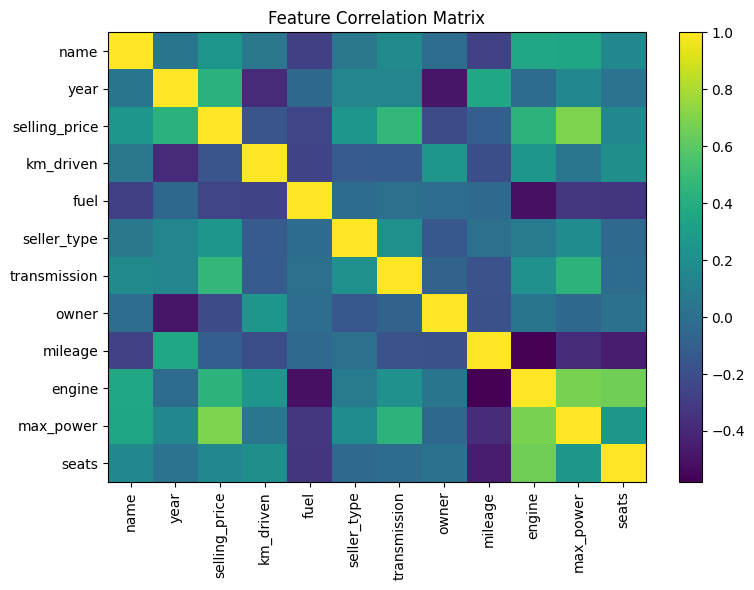

In [67]:
# It shows which features actually influence selling_price.
import matplotlib.pyplot as plt

# Compute correlation matrix
corr = cars_data.corr(numeric_only=True)

plt.figure(figsize=(8, 6))
plt.imshow(corr, aspect='auto')
plt.colorbar()

plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)

plt.title("Feature Correlation Matrix")
plt.tight_layout()
plt.show()



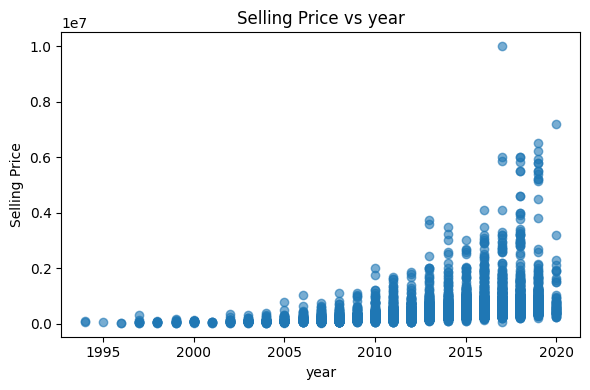

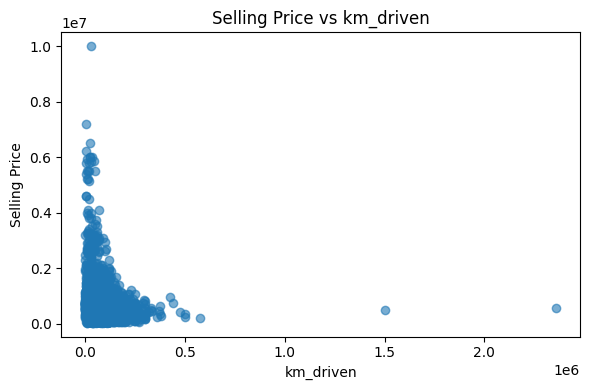

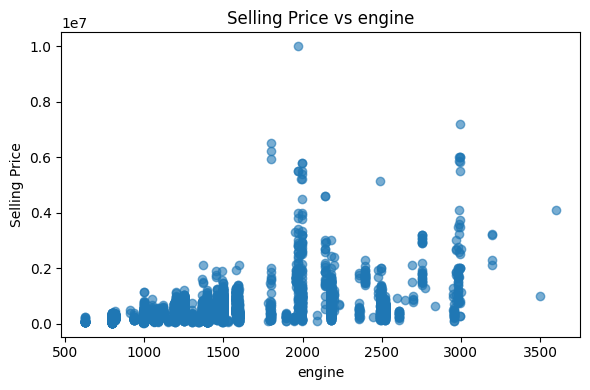

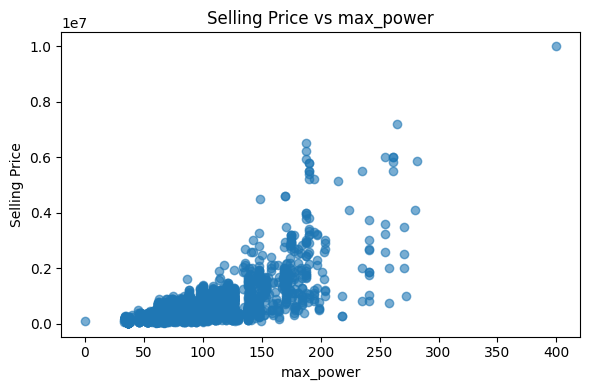

In [66]:
# Feature vs Target (Scatter Plot)
features = ['year', 'km_driven', 'engine', 'max_power']

for feature in features:
    plt.figure(figsize=(6, 4))
    plt.scatter(cars_data[feature], cars_data['selling_price'], alpha=0.6)

    plt.xlabel(feature)
    plt.ylabel("Selling Price")
    plt.title(f"Selling Price vs {feature}")

    plt.tight_layout()
    plt.show()


Predict rendom value

In [49]:
predict =  model.predict(x_test)

In [50]:
predict

array([  19002.75156827,  277784.02096814,  274126.93128143, ...,
        620388.55667254, 1217208.43380143, 1708355.52243407])

In [51]:
x_train.head(1)

,name,year,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,seats
3357,8,2018,24000,1,2,1,1,15.1,2179.0,152.87,7.0


In [52]:
input_data_model = pd.DataFrame(
    [[8,	2000,	10000,	1,	2,	1,	1,	15.1,	2179.0,	152.87,	5.0]],
    columns = ['name',	'year',	'km_driven', 'fuel',	'seller_type', 'transmission',	'owner',	'mileage',	'engine',	'max_power',	'seats']
)

In [53]:
input_data_model

,name,year,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,seats
0,8,2000,10000,1,2,1,1,15.1,2179.0,152.87,5.0


In [54]:
model.predict(input_data_model)

array([799930.05415405])

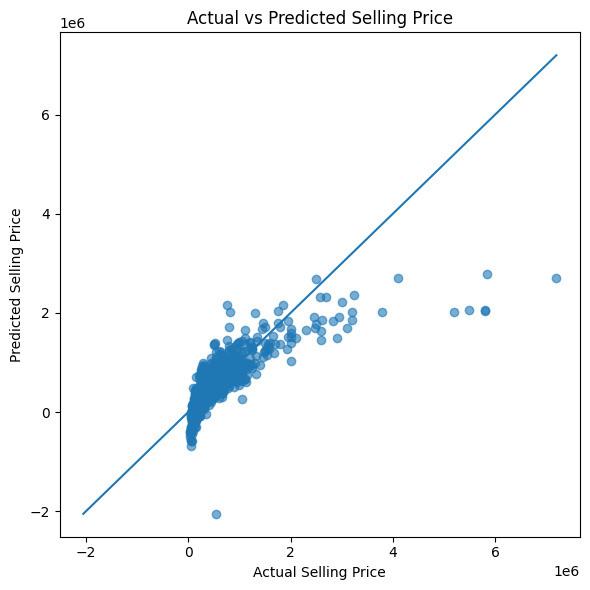

In [68]:
# Generate predictions
y_pred = model.predict(x_test)

plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred, alpha=0.6)

plt.xlabel("Actual Selling Price")
plt.ylabel("Predicted Selling Price")
plt.title("Actual vs Predicted Selling Price")

# Perfect prediction line
min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
plt.plot([min_val, max_val], [min_val, max_val])

plt.tight_layout()
plt.show()


In [55]:
import pickle as pk

In [56]:
pk.dump(model,open('model.pkl','wb'))